## 🏪🛒 Periodic Inventory C-Simulation

- Javier A. González Díaz C-312

Este proyecto de simulación, desarrollado como parte del tercer año de Ciencias de la Computación, aborda el problema de inventario periódico mediante la técnica de simulación de eventos discretos. El objetivo es modelar y analizar el comportamiento de un sistema de inventario para optimizar su gestión y toma de decisiones.

### 🎯 Objetivos
- Implementar un modelo de simulación para analizar políticas de inventario periódico
- Determinar niveles óptimos de reabastecimiento minimizando costos
- Evaluar el impacto de la variabilidad en la demanda y tiempos de entrega


### Importando librerías necesarias 📚


In [11]:
import numpy as np
import pandas as pd
from src.Analyzer.inventory_analyzer import InventoryAnalyzer
from src.InventoryCore.inventory_core import ContinuousReviewInventory
from Plotter.inventory_plotter import InventoryPlotter
from src.Analyzer.sensitive_analyzer import SensitivityAnalyzer
from src.Analyzer.demand_analyzer import DemandDistributionAnalyzer
from src.Analyzer.cost_analyzer import CostStructureAnalyzer
from src.Analyzer.bootstrap_analyzer import BootstrapAnalyzer

### **Funciones auxiliares para generación de eventos** 🧮

##### ➕Generar tiempos de llegada (Poisson)

Los tiempos entre clientes ,según la descripción del problema , siguen una distribución exponencial con parámetro ʎ. Entonces usemos la fórmula que se presenta a continuación.

##### 🧮 Método de la transformada inversa para distribución exponencial

Para generar tiempos entre llegadas que sigan una distribución exponencial con parámetro λ, utilizamos el método de la transformada inversa:

1. Si X tiene distribución exponencial con parámetro λ, su función de distribución acumulada es:

    F(x) = 1 - e^(-λx)

2. Si U es una variable aleatoria uniforme en [0,1], entonces:
    F^(-1)(U) sigue la distribución deseada

3. Despejando:
    U = 1 - e^(-λt)
    e^(-λt) = 1 - U
    -λt = ln(1 - U)
    t = -(1/λ) ln(1 - U)

4. Como 1-U también es uniforme en [0,1], podemos simplificar a:
    t = -(1/λ) ln(U)

Esta es la fórmula implementada en la función de generación de tiempos.

### 📦 Generación de la demanda D ~ G 

Se implementó una función auxiliar que permite generar valores de demanda discretos, definidos por una lista de posibles valores y sus respectivas probabilidades. Esto permite probar distintas distribuciones de demanda como parte del análisis de sensibilidad del modelo.Dicha función luego pasará a un segundo plano , en el análisis del impacto que tendrán las distintas **Distribuciones**.


## 🔁 Bucle Principal de Simulación (ContinuousReviewInventory)

### Paradigma de Eventos Discretos
La simulación avanza cronológicamente procesando **eventos clave**, actualizando el estado del sistema y registrando métricas en cada paso. 

---

### ⏳ Tipos de Eventos
1. **`ARRIVAL`**: Llegada de un cliente (genera demanda aleatoria)  
2. **`DELIVERY`**: Recepción de un pedido pendiente  

El sistema siempre procesa el **evento más cercano** en el tiempo usando una cola de prioridad.

---

### 📦 Evento 1: Llegada de Cliente (`ARRIVAL`)
1. **Actualización de costos**:  
   - Calcula el costo de almacenamiento acumulado hasta el momento del evento.  
2. **Generación de demanda**:  
   - La demanda `D` se muestrea de una distribución configurable (ej: Poisson).  
3. **Gestión de inventario**:  
   - Se vende `w = min(D, inventario_disponible)`.  
   - Si `D > inventario`, se registran unidades/clientes perdidos.  
4. **Decisión de pedido**:  
   - Si el inventario cae bajo el umbral `s` y no hay pedidos pendientes:  
     - Se ordena `S - inventario` unidades.  
     - Programa un nuevo evento `DELIVERY` en `t + lead_time`.  
5. **Próxima llegada**:  
   - Agenda el siguiente `ARRIVAL` usando el proceso de Poisson.

---

### 📦 Evento 2: Recepción de Pedido (`DELIVERY`)
1. **Actualización de costos**:  
   - Calcula el costo de almacenamiento hasta la llegada del pedido.  
2. **Ajuste de inventario**:  
   - Añade las unidades recibidas al inventario.  
3. **Costos asociados**:  
   - Aplica la función de costo de pedido (puede incluir costos fijos + variables).  
4. **Reset de estado**:  
   - Marca que no hay pedidos pendientes.  

---

### 🎯 Criterio de Terminación
La simulación termina cuando:  
- El tiempo actual `t` supera el horizonte de simulación `T`.  
- No quedan eventos por procesar.  

**Métricas finales calculadas:**  

| Concepto               | Fórmula                          | Descripción                                  |
|------------------------|----------------------------------|----------------------------------------------|
| Ganancia Promedio      | $(R - C - H)/T$                 | Beneficio neto por unidad de tiempo         |
| Nivel de Servicio      | $1 - \frac{\text{unidades\_perdidas}}{\text{demanda\_total}}$ | % demanda satisfecha        |
| Inventario Promedio    | $\frac{\text{área\_bajo\_curva}}{T}$ | Nivel medio de stock durante la simulación |

**Otras métricas clave:**  
- Costos totales de pedidos (`C`).  
- Ingresos totales (`R`).  
- Tasa de clientes perdidos.  
- Rotación de inventario.  

---

### Diagrama Conceptual del Flujo
```mermaid
graph TD
    A[Inicio: Inventario = S] --> B{Próximo Evento}
    B -->|ARRIVAL| C[Atender Demanda]
    C --> D[¿Inventario < s?]
    D -->|Sí| E[Ordenar S - inventario]
    D -->|No| F[Programar próximo ARRIVAL]
    B -->|DELIVERY| G[Recibir Pedido]
    G --> H[Actualizar Inventario]
    H --> B
    B -->|t >= T| I[Calcular Métricas Finales]

## 📦🚛🏪 **Implementación concreta del sistema en archivo adjunto**
#### 📋📦🔍*Con el objetivo de encapsular y reutilizar este sistema que se va a simular se ha encapsulado en una clase llamada ContinousReviewInventory que posee cada uno de los parámetros anteriormente expuestos ,necesarios para representar de la mejor forma el problema inicial descrito al comienzo de este documento.**Mirar inventory_core.py adjunto***

## **Análisis de interés sobre la simulación** 🔮📈➕

### **Explorando inicialmente los resultados de N simulaciones** 🤔💭

### **Optimización del par (s,S)** 📈

Una pregunta interesante y de verdadero valor es , dadas algunas condiciones iniciales , qué pareja (s,S) maximiza la ganancia promedio.

**Necesidad**: Encontrar la combinación \(s,S\) que maximiza la ganancia promedio por unidad de tiempo, para tomar decisiones de reposición eficientes.  
**Pregunta**: ¿Qué valores de \(s\) y \(S\) nos dan el mayor $\bar\pi = \frac{R - C - H}{T}$ 

Analizando s: 100%|██████████| 10/10 [00:02<00:00,  4.63it/s]


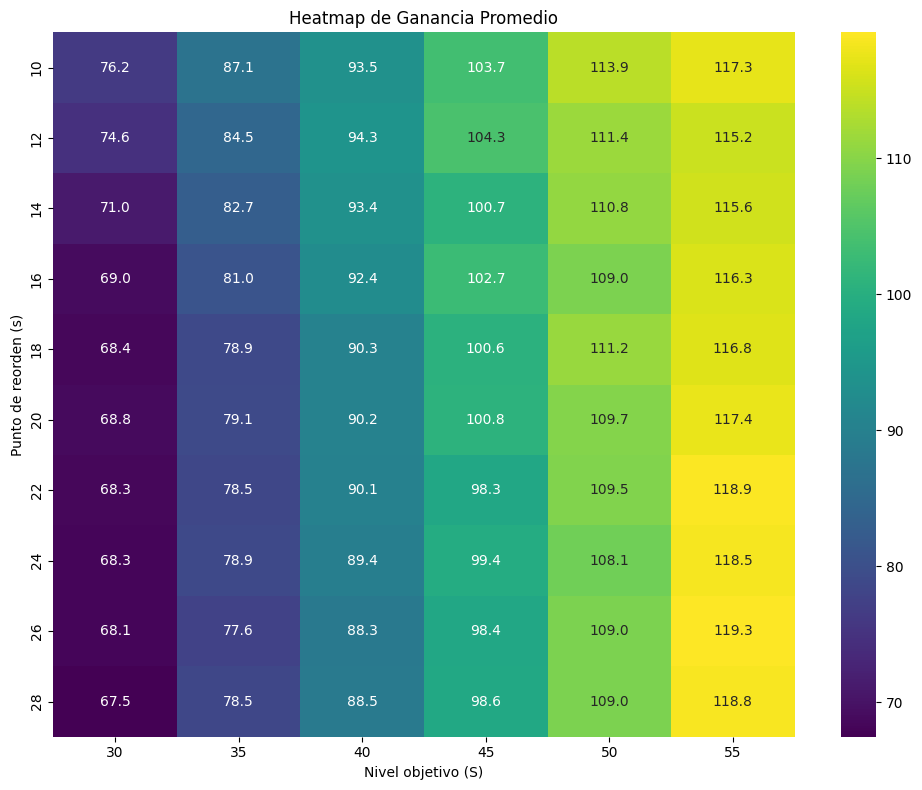

In [12]:
 # Configuración base
from matplotlib import pyplot as plt


base_params = {
        'lambda_': 5,
        'lead_time': 2,
        'demand_dist': lambda: np.random.poisson(5),
        'order_cost_func': lambda x: 10 + 1*x,  # Costo fijo + variable
        'holding_cost': 0.1,
        'unit_revenue': 10,
        'time_horizon': 100
    }

# Análisis de optimal (s,S)
s_values = np.arange(10, 30, 2)
S_values = np.arange(30, 60, 5)
analyzer = InventoryAnalyzer()
resultados = analyzer.grid_search(s_values, S_values, base_params)

# 2. Visualización Heatmap
plotter = InventoryPlotter()
plotter.plot_heatmap(
    resultados, 
    metric='profit_mean',
    title='Heatmap de Ganancia Promedio'
)
plt.show()

### 📈 **Histograma 3D para facilitar la vista de las tuplas y la respectiva ganancia promedio que causan** 

Columnas disponibles: [{'s': np.int64(10), 'S': np.int64(30), 'profit_mean': np.float64(76.19038204721994), 'profit_std': np.float64(1.0750565225726987)}, {'s': np.int64(10), 'S': np.int64(35), 'profit_mean': np.float64(87.09948496318562), 'profit_std': np.float64(2.7930566972261768)}, {'s': np.int64(10), 'S': np.int64(40), 'profit_mean': np.float64(93.49839295786259), 'profit_std': np.float64(2.700764289750346)}, {'s': np.int64(10), 'S': np.int64(45), 'profit_mean': np.float64(103.67468084181185), 'profit_std': np.float64(1.6371427639707867)}, {'s': np.int64(10), 'S': np.int64(50), 'profit_mean': np.float64(113.93700084874872), 'profit_std': np.float64(1.6284028619067192)}, {'s': np.int64(10), 'S': np.int64(55), 'profit_mean': np.float64(117.31948683982962), 'profit_std': np.float64(2.9410540511060588)}, {'s': np.int64(12), 'S': np.int64(30), 'profit_mean': np.float64(74.62892692691833), 'profit_std': np.float64(1.6304487902774247)}, {'s': np.int64(12), 'S': np.int64(35), 'profit_mean

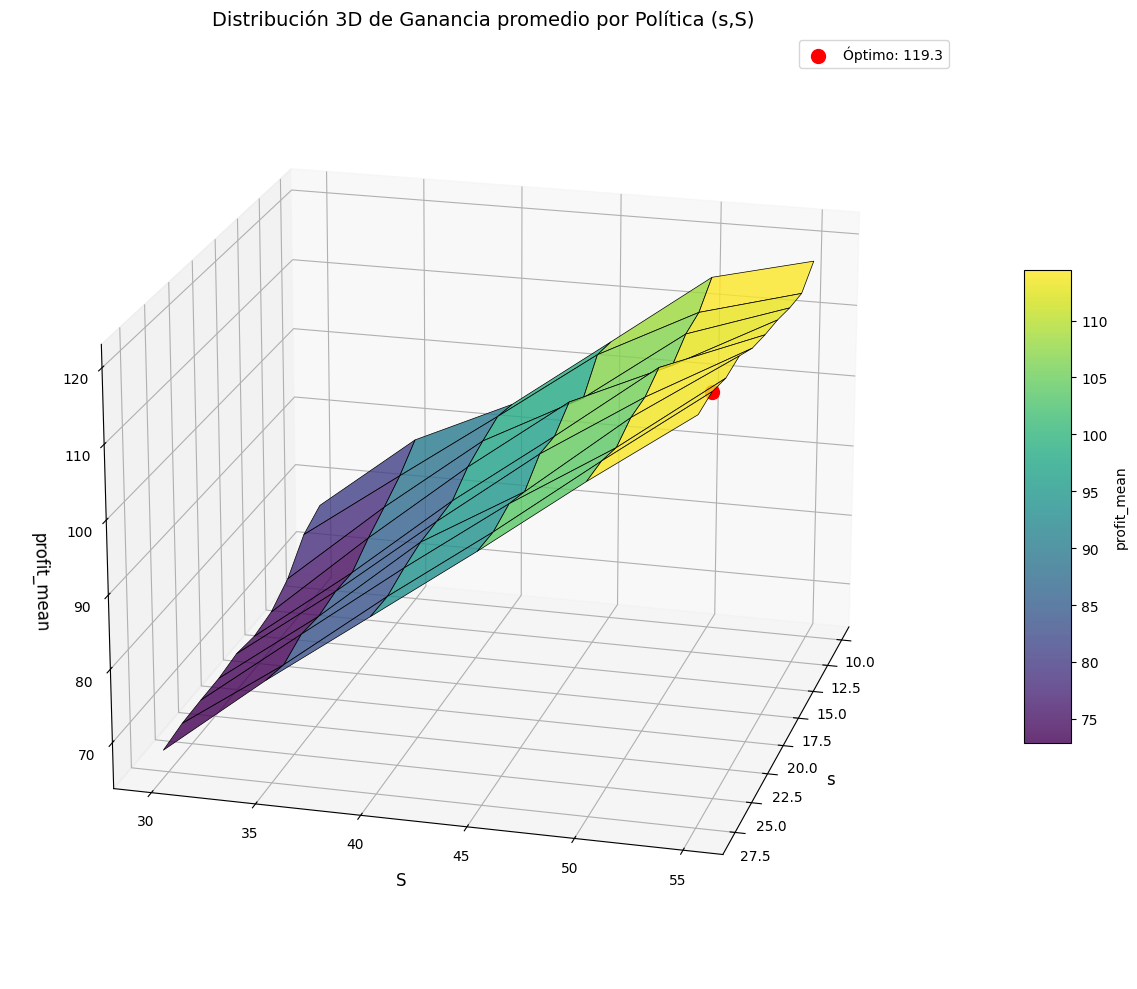

In [13]:
print("Columnas disponibles:", resultados)
try:
    plotter.plot_policy_3d(resultados,metric='profit_mean',elev=20,azim=15)
except Exception as e:
    print(f"Error al generar gráfico: {str(e)}")
    print("Verifica que los datos tengan las columnas requeridas")

**Interpretación**  
- Observamos que la ganancia aumenta rápido al incrementar \(S\) hasta cierto punto,  
  luego decrece (costos de holding).  
- Esto confirma el trade‑off entre pedidos grandes (menos frecuencia) y costos de almacenamiento.


###  **Sensibilidad a la tasa de llegada \(\lambda\) ʎ**🔍

**Necesidad**: La demanda puede variar estacionalmente. Queremos saber  
cómo afecta un aumento o disminución de \(\lambda\) a la rentabilidad.  
**Pregunta**: ¿Cómo cambia la ganancia promedio y el nivel de servicio al variar \(\lambda\)?


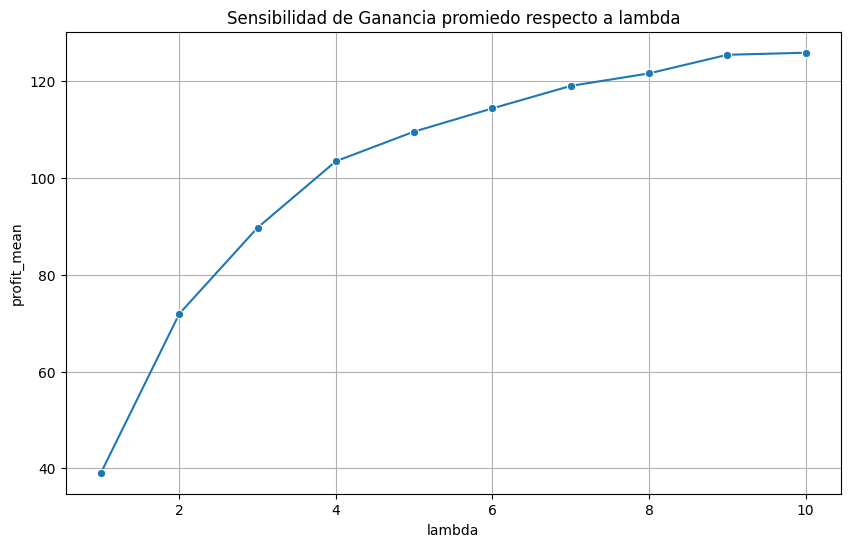

In [14]:
# Análisis de sensibilidad para lambda
lambda_values = np.linspace(1, 10, 10)
sens_results = []
for l in lambda_values:
        params = base_params.copy()
        params['lambda_'] = l
        metrics = []
        for _ in range(10):
            sim = ContinuousReviewInventory(s=20, S=50, **params)
            sim.run()
            metrics.append(sim.get_metrics()['average_profit_per_time'])
        sens_results.append({'lambda': l, 'profit_mean': np.mean(metrics)})
    
plotter.plot_sensitivity(pd.DataFrame(sens_results), 'lambda')

**Interpretación**  
- A medida que ʎcrece, la ganancia promedio inicialmente sube (más ventas),  
  pero luego cae si el inventario no se ajusta (pérdidas por stockouts).  
Realmente este análisis agnóstico o separado de otros parámetros relevantes no provee toda la información necesaria , ya que un aumento excesivo de la demanda , puede aumentar a otros aspectos negativos como son un mayor total de clientes insatisfechos (que no satisfacen su demanda)

### **Sensibilidad al lead time \(L\) , existiendo simultáneamente un aumento de la tasa de llegada** ⌚🚛 

**Necesidad**: Los retrasos logísticos impactan en la disponibilidad de stock , lo cual provoca condiciones negativas cuando aumenta la demanda (ʎ).  
**Pregunta**: ¿Cómo varían la ganancia y el servicio cuando \(L\) aumenta , simultanea e independientemente de la *demanda*?


Analizando lead_time: 100%|██████████| 10/10 [00:00<00:00, 605.87it/s]


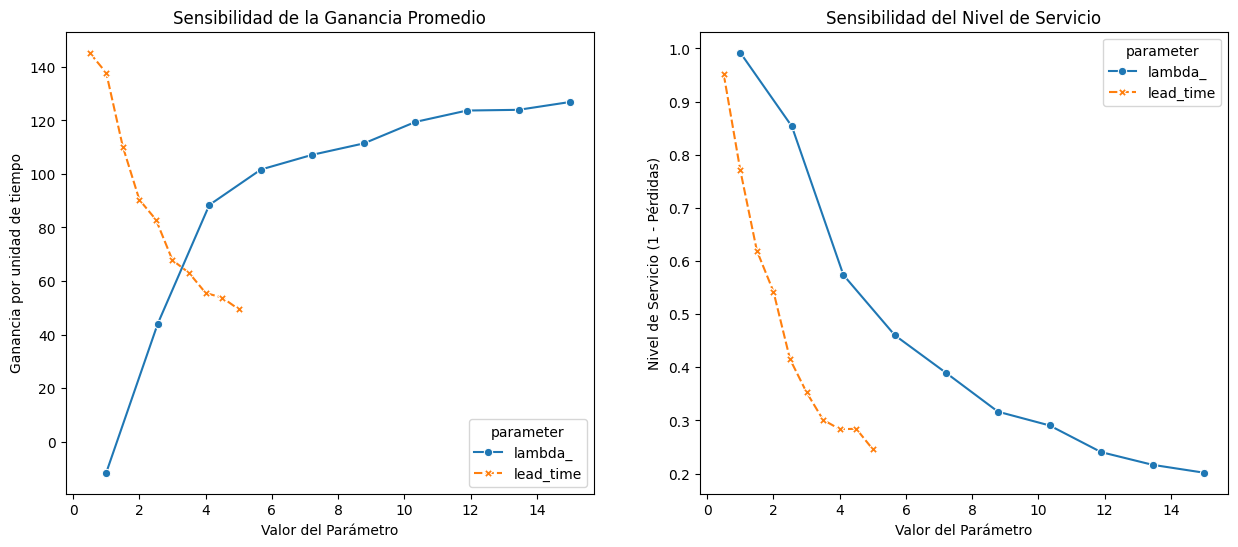

In [15]:

base_params = {
        'lambda_': 5,
        'lead_time': 2,
        'demand_dist': lambda: np.random.poisson(5),
        'order_cost_func': lambda x: 50 + 10*x,
        'holding_cost': 2,
        'unit_revenue': 20,
        'time_horizon': 100
    }
    
    # 1. Análisis de Sensibilidad
param_ranges = {
        'lambda_': np.linspace(1, 15, 10),
        'lead_time': np.linspace(0.5, 5, 10)
}
sens_results = SensitivityAnalyzer.analyze(base_params, param_ranges)
SensitivityAnalyzer.plot_results(sens_results)

**Interpretación**  
- Con \(L\) mayor, la ganancia cae con el avance de la demanda , pero el nivel de servicio cae estrepitósamente:  
  se necesita más inventario de seguridad para mitigar retrasos.  
- Este análisis ayuda a negociar plazos de entrega o ajustar la política $((s^*,S^*))$.

### 4. Distribución de la demanda 🙋🙋🙋

**Necesidad**: Las propiedades de \(G\) (varianza, colas pesadas) afectan el inventario.  
**Pregunta**: ¿Qué tan robusta es la política óptima ante diferentes distribuciones de demanda?

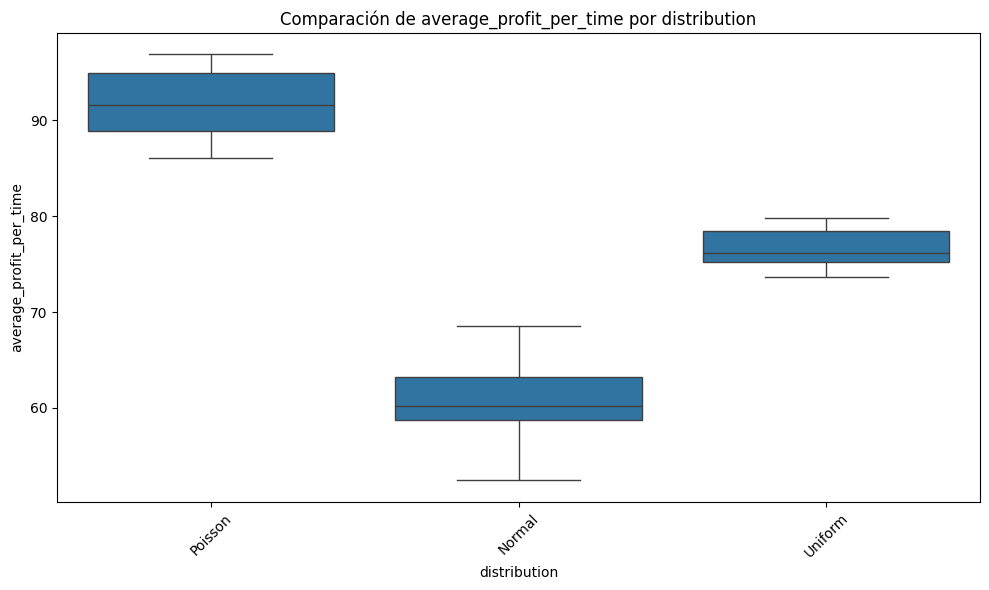

In [16]:
# Análisis de distribuciones de demanda D 

# Definir distribuciones a probar
distributions = {
    'Poisson': {'lambda': 5},
    'Normal': {'mu': 3, 'sigma': 1.5},
    'Uniform': {'a': 1, 'b': 6}
}

# Ejecutar análisis
dist_results = DemandDistributionAnalyzer.analyze(base_params, distributions)
plotter.plot_comparison(dist_results, 'distribution', 'average_profit_per_time')

**Interpretación**  🔍🔍🔍
- De las tres distribuciones probadas, la demanda **normal** arrojó la **peor** ganancia promedio y nivel de servicio. Su naturaleza continua y simétrica genera valores extremos que dificultan dimensionar el inventario con precisión.  
- La distribución **uniforme** quedó en **segundo lugar**, con un desempeño intermedio: su variabilidad constante en un rango amplio también provoca tanto stockouts como excesos de inventario.  
- La **Poisson** resultó ser la **mejor**, ofreciendo la mayor ganancia promedio y nivel de servicio. Al ser discreta y concentrarse alrededor de su media, facilita predecir la demanda y ajustar correctamente la política \((s,S)\).  


### 5. Estructura de costos de pedido 🚛💰

**Necesidad**: El costo de ordenar puede ser fijo, variable o mixto, y esto cambia  
la frecuencia y tamaño de los pedidos.  
**Pregunta**: ¿Cómo varían ganancia y servicio con diferentes modelos de costo?


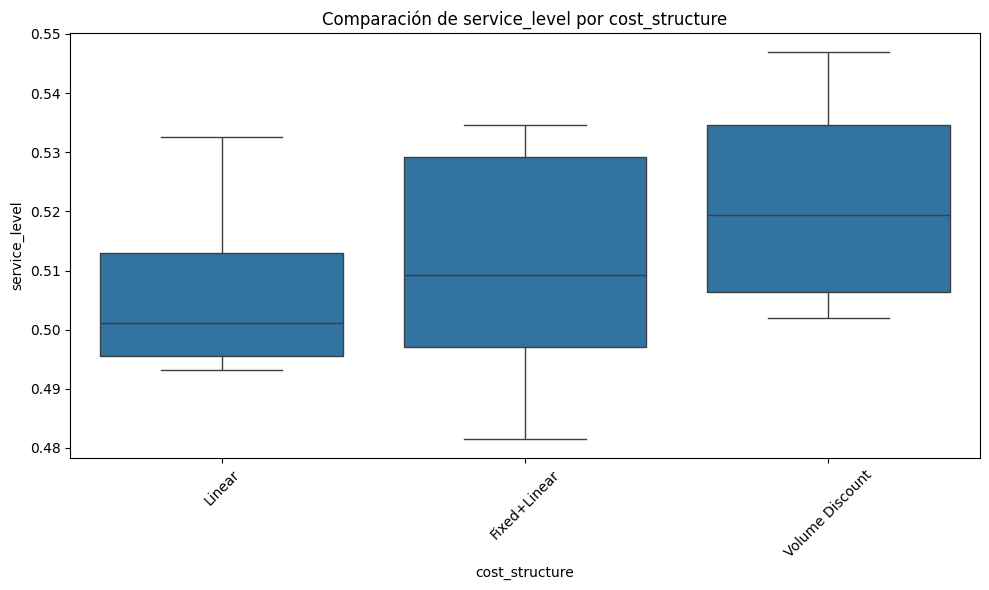

In [17]:
#  Análisis de Costos
cost_structures = {
        'Linear': lambda x: 10*x,
        'Fixed+Linear': lambda x: 50 + 8*x,
        'Volume Discount': lambda x: 100 + 5*x if x < 20 else 80 + 4*x
    }
cost_results = CostStructureAnalyzer.analyze(base_params, cost_structures)
plotter.plot_comparison(cost_results, 'cost_structure', 'service_level')

**Interpretación**  🔍💰
- Los modelos **Volume Discount** y **Fixed + Linear** alcanzaron los **mejores niveles de servicio**. Al incentivar pedidos más grandes (ya sea por descuento por volumen o por costo fijo elevado más variable), se reducen los stockouts y se mejora la disponibilidad.  
- El modelo **Linear** (solo costo variable) quedó en **último lugar**, aunque no muy rezagado. Al no tener incentivo para agrupar pedidos, tiende a realizar compras más frecuentes y pequeñas, lo que mantiene un servicio razonable pero ligeramente inferior al de las estructuras mixtas.  


### 6. Bootstrap de intervalos de confianza 🤔💭✅

**Necesidad**: Cuantificar la incertidumbre de la ganancia promedio para la política óptima.  
**Pregunta**: ¿Con qué nivel de confianza podemos afirmar el valor estimado de $\bar\pi$ ?


Bootstrap: 100%|██████████| 1000/1000 [00:01<00:00, 592.68it/s]


Resultados del Bootstrap:
IC 95% para π̄: [84.18, 99.61]


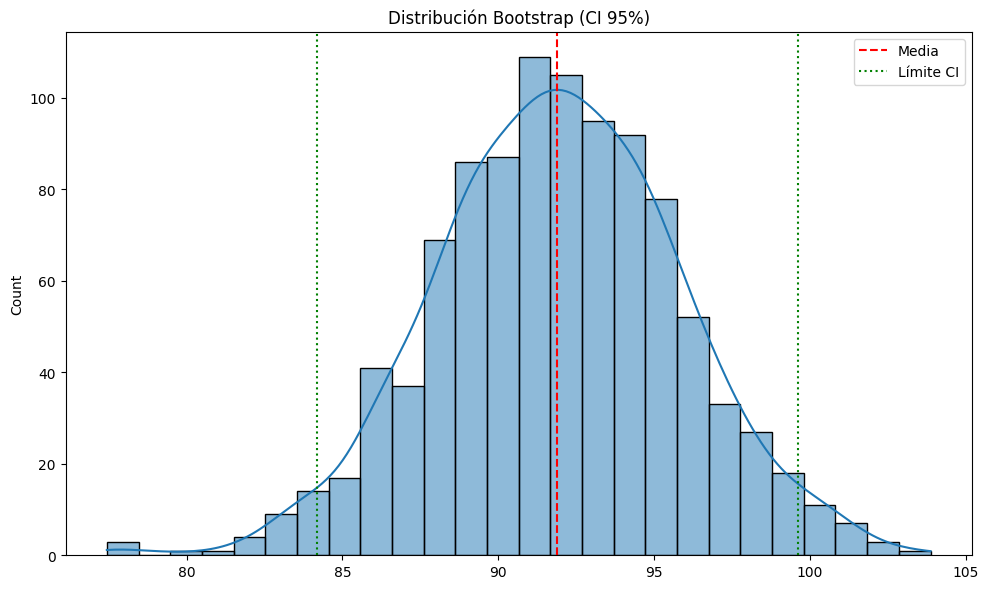

In [20]:
# Bootstrap
sim = ContinuousReviewInventory(s=20, S=50, **base_params)
bootstrap_results = BootstrapAnalyzer.analyze(sim)
plotter.plot_bootstrap(bootstrap_results)
print("Resultados del Bootstrap:")
print(f"IC 95% para π̄: [{bootstrap_results['ci_lower']:.2f}, {bootstrap_results['ci_upper']:.2f}]")

**Interpretación**  📈🤔
El intervalo de confianza del 95 % para la ganancia promedio por unidad de tiempo (π̄) está entre **84.18** y **99.61**. Esto indica que, con alta confianza, el valor real de la ganancia esperada se encuentra dentro de ese rango, considerando la variabilidad inherente al sistema.

Este análisis permite evaluar la **robustez de la política (s=20, S=50)**: dado que el intervalo es relativamente estrecho y se encuentra en una región alta de ganancia, podemos decir que la política es **estable y confiable** en términos de rendimiento económico, incluso frente a la incertidumbre inherente al modelo estocástico.


## 🔍 **Próximos pasos**

El desarrollo de este simulador no solo permite representar el comportamiento de un sistema de inventario bajo revisión continua, algo útil para la -vida real-, sino que también habilita un **entorno flexible para el análisis y la toma de decisiones estratégicas**.

A lo largo de este estudio se han implementado diversos analizadores especializados que permiten explorar diferentes aspectos del sistema. Se invita al lector a experimentar con ellos:

- 📊 **`InventoryAnalyzer`**  
  Ideal para explorar políticas de pedido. Permite encontrar tupla(s) (s, S) óptimas mediante búsqueda en malla. Prueba distintos horizontes de tiempo y estructuras de demanda para encontrar políticas robustas.

- ⚙️ **`SensitivityAnalyzer`**  
  Úsalo para entender **qué tan sensible es tu sistema** ante parámetros como la tasa de demanda (`λ`) o el tiempo de entrega (`L`). Una herramienta clave para análisis de riesgos y robustez.

- 📈 **`DemandDistributionAnalyzer`**  
  Explora el **impacto de diferentes distribuciones de demanda** sobre el rendimiento del sistema. Ideal para evaluar políticas bajo distintos escenarios de incertidumbre.

- 💰 **`CostStructureAnalyzer`**  
  Permite comparar cómo distintas estructuras de costos afectan métricas clave como el nivel de servicio o la ganancia. Fundamental para adaptar el modelo a diferentes realidades empresariales.

- 📦 **`BootstrapAnalyzer`**  
  Evalúa la **variabilidad de las métricas simuladas**. Genera intervalos de confianza y ayuda a verificar la confiabilidad estadística de tus resultados.

---

Cada uno de estos analizadores es una herramienta poderosa por sí misma, pero su verdadero valor se maximiza al usarlos **en conjunto**. Experimenta, ajusta parámetros y descubre las combinaciones que maximizan tu rendimiento bajo incertidumbre.

## **¡Explora, analiza y optimiza tu sistema de inventario!** 📋🚛🚀
